# 🚗 Fuel Efficiency Prediction Model
## Vehicle Telematics — CatBoost Regression (Final)

**Goal:** Predict fuel efficiency (kpl) from OBD sensor readings.

**Model:** CatBoost Regressor — selected over Random Forest because:
- Feature importance is more evenly distributed (no single-feature dominance)
- Handles `deviceID` as native categorical — no one-hot expansion needed
- Importance ranking aligns with ECU logic: gear → throttle → rpm/speed ratio → engine load

**Removed features vs v1:**
- `rpm` — covered by `rpm_per_speed`, multicollinearity risk
- `speed_zone_ord` — 0.3% importance, redundant with `speed` and `rpm_per_speed`
- `power_proxy` — highly correlated with `rpm_per_speed × eLoad`, adds noise

**Key engineered feature:** `est_gear` — gear position estimated via KMeans on RPM/speed ratio,
calibrated independently per vehicle. Not present in raw OBD data.

**Author:** Paşan Sancak · [LinkedIn](https://linkedin.com/in/pasansancak) · [GitHub](https://github.com/pasansancak)

## 0. Setup

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

os.makedirs('../outputs', exist_ok=True)
print('Setup complete ✓')

Setup complete ✓


## 1. Load & Clean Data

In [28]:
df = pd.read_csv('../data/allcars.csv', low_memory=False)

numeric_cols = ['tripID','deviceID','gps_speed','battery','cTemp','dtc',
                'eLoad','iat','imap','kpl','maf','rpm','speed','tAdv','tPos']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['timeStamp'] = pd.to_datetime(df['timeStamp'], errors='coerce')
df = df.dropna(subset=['gps_speed','rpm','eLoad','kpl']).reset_index(drop=True)

# Range filters — remove sensor glitches
df = df[df['speed'].between(0, 150)]
df = df[df['eLoad'].between(0, 100)]
df = df[df['kpl'].between(0, 25)]
df = df[df['rpm'].between(0, 7000)]
if 'cTemp' in df.columns:
    df['cTemp'] = df['cTemp'].where(df['cTemp'].between(-10, 130), np.nan)

df = df.sort_values(['deviceID','tripID','timeStamp']).reset_index(drop=True)

# Exclude vehicles with no or unreliable KPL sensor
kpl_by_device      = df.groupby('deviceID')['kpl'].sum()
NO_KPL_DEVICES     = kpl_by_device[kpl_by_device == 0].index.tolist()
UNRELIABLE_DEVICES = [7.0]
EXCLUDED           = NO_KPL_DEVICES + UNRELIABLE_DEVICES

df_model = df[
    (df['speed'] > 2) &
    (df['kpl'] > 0) &
    (~df['deviceID'].isin(EXCLUDED))
].copy()

print(f'Shape         : {df_model.shape}')
print(f'Excluded      : {[int(d) for d in EXCLUDED]}')
print(f'Vehicles used : {sorted(df_model["deviceID"].unique().astype(int).tolist())}')

Shape         : (1582926, 17)
Excluded      : [0, 1, 2, 4, 11, 14, 7]
Vehicles used : [3, 5, 6, 8, 9, 10, 12, 16]


## 2. Feature Engineering

| Feature | Type | Description | ECU Relevance |
|---|---|---|---|
| `est_gear` | Engineered | KMeans gear estimation (1–6) per vehicle | Direct ECU injection modifier |
| `rpm_per_speed` | Engineered | RPM / (speed+1) — continuous gear ratio | Raw gear signal |
| `throttle_load` | Engineered | tPos × eLoad / 100 — driving aggressiveness | Injection demand proxy |
| `tPos` | Raw OBD | Throttle position (%) | Primary injection trigger |
| `eLoad` | Raw OBD | Engine load (%) — ECU computed | Injection quantity output |
| `speed` | Raw OBD | Vehicle speed (km/h) | Context for gear ratio |
| `cTemp` | Raw OBD | Coolant temperature | Cold-start enrichment |
| `deviceID` | Identifier | Vehicle ID — native categorical | Per-vehicle ECU calibration |

In [29]:
# --- Gear estimation: KMeans per vehicle ---
# OBD data has no gear sensor.
# We estimate gear from RPM/speed ratio — higher ratio = lower gear.
# Clustering is done per vehicle to respect different engine/transmission specs.

df_model['gear_ratio'] = df_model['rpm'] / df_model['speed']

def estimate_gears_kmeans(vehicle_df, n_gears=6):
    """
    Estimates gear position (1=lowest, 6=highest) using KMeans
    on RPM/speed ratio, calibrated per vehicle.
    """
    ratios = vehicle_df['gear_ratio'].dropna().values.reshape(-1, 1)
    if len(ratios) < n_gears * 10:
        vehicle_df = vehicle_df.copy()
        vehicle_df['est_gear'] = 3
        return vehicle_df
    km = KMeans(n_clusters=n_gears, random_state=42, n_init=10)
    km.fit(ratios)
    center_rank = {
        old: i + 1
        for i, old in enumerate(
            sorted(range(n_gears), key=lambda x: km.cluster_centers_[x], reverse=True)
        )
    }
    vehicle_df = vehicle_df.copy()
    vehicle_df['est_gear'] = [
        center_rank[c]
        for c in km.predict(vehicle_df['gear_ratio'].fillna(0).values.reshape(-1, 1))
    ]
    return vehicle_df

parts = []
for dev_id, vdf in df_model.groupby('deviceID'):
    parts.append(estimate_gears_kmeans(vdf))
df_model = pd.concat(parts).reset_index(drop=True)

# --- Engineered features ---
# Continuous gear ratio signal (complements discrete est_gear)
df_model['rpm_per_speed']  = df_model['rpm'] / (df_model['speed'] + 1)

# Driving aggressiveness: throttle × engine load
df_model['throttle_load']  = df_model['tPos'] * df_model['eLoad'] / 100

# Fill coolant temp NaNs with median
if 'cTemp' in df_model.columns:
    df_model['cTemp'] = df_model['cTemp'].fillna(df_model['cTemp'].median())

print('Feature engineering complete ✓')
print('Removed vs v1: rpm, speed_zone_ord, power_proxy')

Feature engineering complete ✓
Removed vs v1: rpm, speed_zone_ord, power_proxy


## 3. Prepare Features & Split

In [30]:
# Final feature set — aligned with ECU injection logic
FEATURES = [
    'est_gear',       # engineered — primary gear signal
    'tPos',           # throttle position — injection trigger
    'rpm_per_speed',  # continuous gear ratio
    'eLoad',          # engine load — ECU injection output
    'throttle_load',  # aggressiveness proxy
    'speed',          # vehicle speed
    'cTemp',          # coolant temp — cold start effects
    'deviceID'        # vehicle identifier — native categorical in CatBoost
]

df_model['deviceID_int'] = df_model['deviceID'].astype(int)

feature_cols = [
    'est_gear', 'tPos', 'rpm_per_speed', 'eLoad',
    'throttle_load', 'speed', 'cTemp', 'deviceID_int'
]

X = df_model[feature_cols].fillna(0).copy()
X = X.rename(columns={'deviceID_int': 'deviceID'})
y = df_model['kpl'].values

cat_feature_idx = [X.columns.get_loc('deviceID')]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Features : {list(X.columns)}')
print(f'Train    : {len(y_train):,}  |  Test : {len(y_test):,}')

Features : ['est_gear', 'tPos', 'rpm_per_speed', 'eLoad', 'throttle_load', 'speed', 'cTemp', 'deviceID']
Train    : 1,266,340  |  Test : 316,586


## 4. Train CatBoost Model

In [31]:
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

cb_model.fit(
    X_train, y_train,
    cat_features=cat_feature_idx,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

y_pred = cb_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f'\nCatBoost Final  →  R²: {r2:.4f}  RMSE: {rmse:.4f} kpl  MAE: {mae:.4f} kpl')

0:	learn: 4.5026804	test: 4.4975782	best: 4.4975782 (0)	total: 99.3ms	remaining: 1m 39s
200:	learn: 1.6672182	test: 1.6733759	best: 1.6733759 (200)	total: 13.5s	remaining: 53.5s
400:	learn: 1.5828262	test: 1.5905059	best: 1.5905059 (400)	total: 27.3s	remaining: 40.8s
600:	learn: 1.5487187	test: 1.5579486	best: 1.5579486 (600)	total: 41.1s	remaining: 27.3s
800:	learn: 1.5285821	test: 1.5394144	best: 1.5394144 (800)	total: 55s	remaining: 13.7s
999:	learn: 1.5143965	test: 1.5267392	best: 1.5267392 (999)	total: 1m 8s	remaining: 0us

bestTest = 1.526739236
bestIteration = 999


CatBoost Final  →  R²: 0.8928  RMSE: 1.5267 kpl  MAE: 0.9257 kpl


## 5. Predicted vs Actual

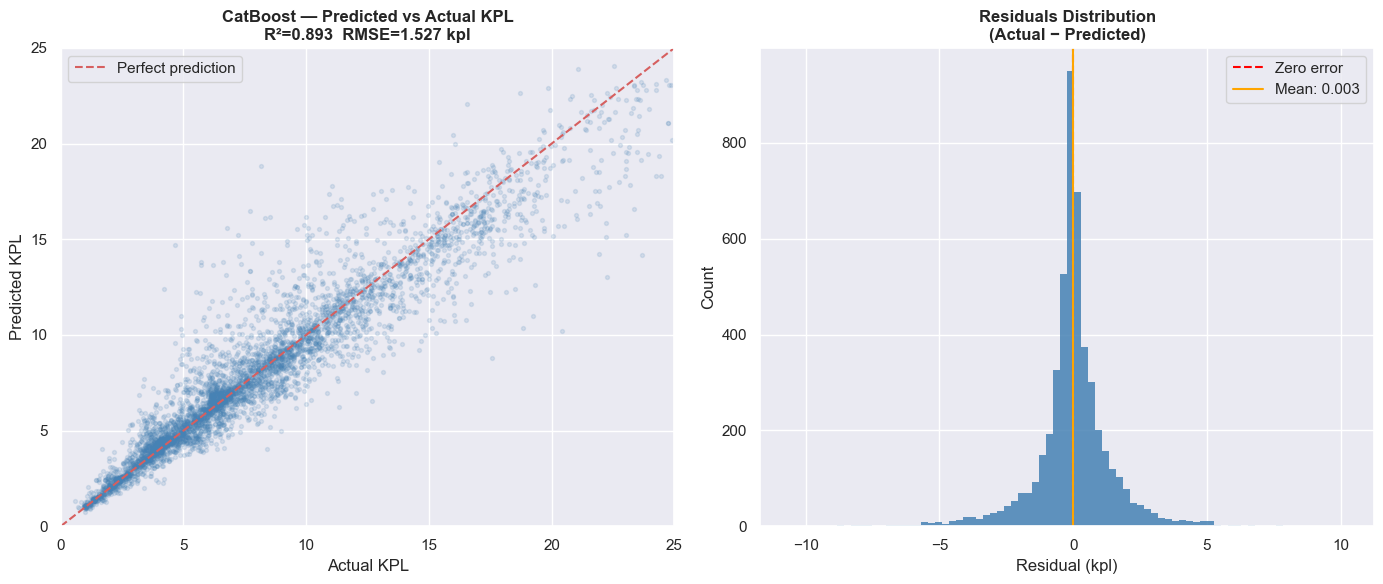

Saved -> outputs/06_predicted_vs_actual.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample_idx = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)
y_test_s   = y_test[sample_idx]
y_pred_s   = y_pred[sample_idx]

# Predicted vs Actual scatter
axes[0].scatter(y_test_s, y_pred_s, alpha=0.15, s=8, color='steelblue')
axes[0].plot([0,25],[0,25], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlim([0,25])
axes[0].set_ylim([0,25])
axes[0].set_title(f'CatBoost — Predicted vs Actual KPL\nR²={r2:.3f}  RMSE={rmse:.3f} kpl',
                  fontweight='bold')
axes[0].set_xlabel('Actual KPL')
axes[0].set_ylabel('Predicted KPL')
axes[0].legend()

# Residuals distribution
residuals = y_test_s - y_pred_s
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='-', lw=1.5,
                label=f'Mean: {residuals.mean():.3f}')
axes[1].set_title('Residuals Distribution\n(Actual − Predicted)', fontweight='bold')
axes[1].set_xlabel('Residual (kpl)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/06_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/06_predicted_vs_actual.png')

## 6. Per-Vehicle Predictions

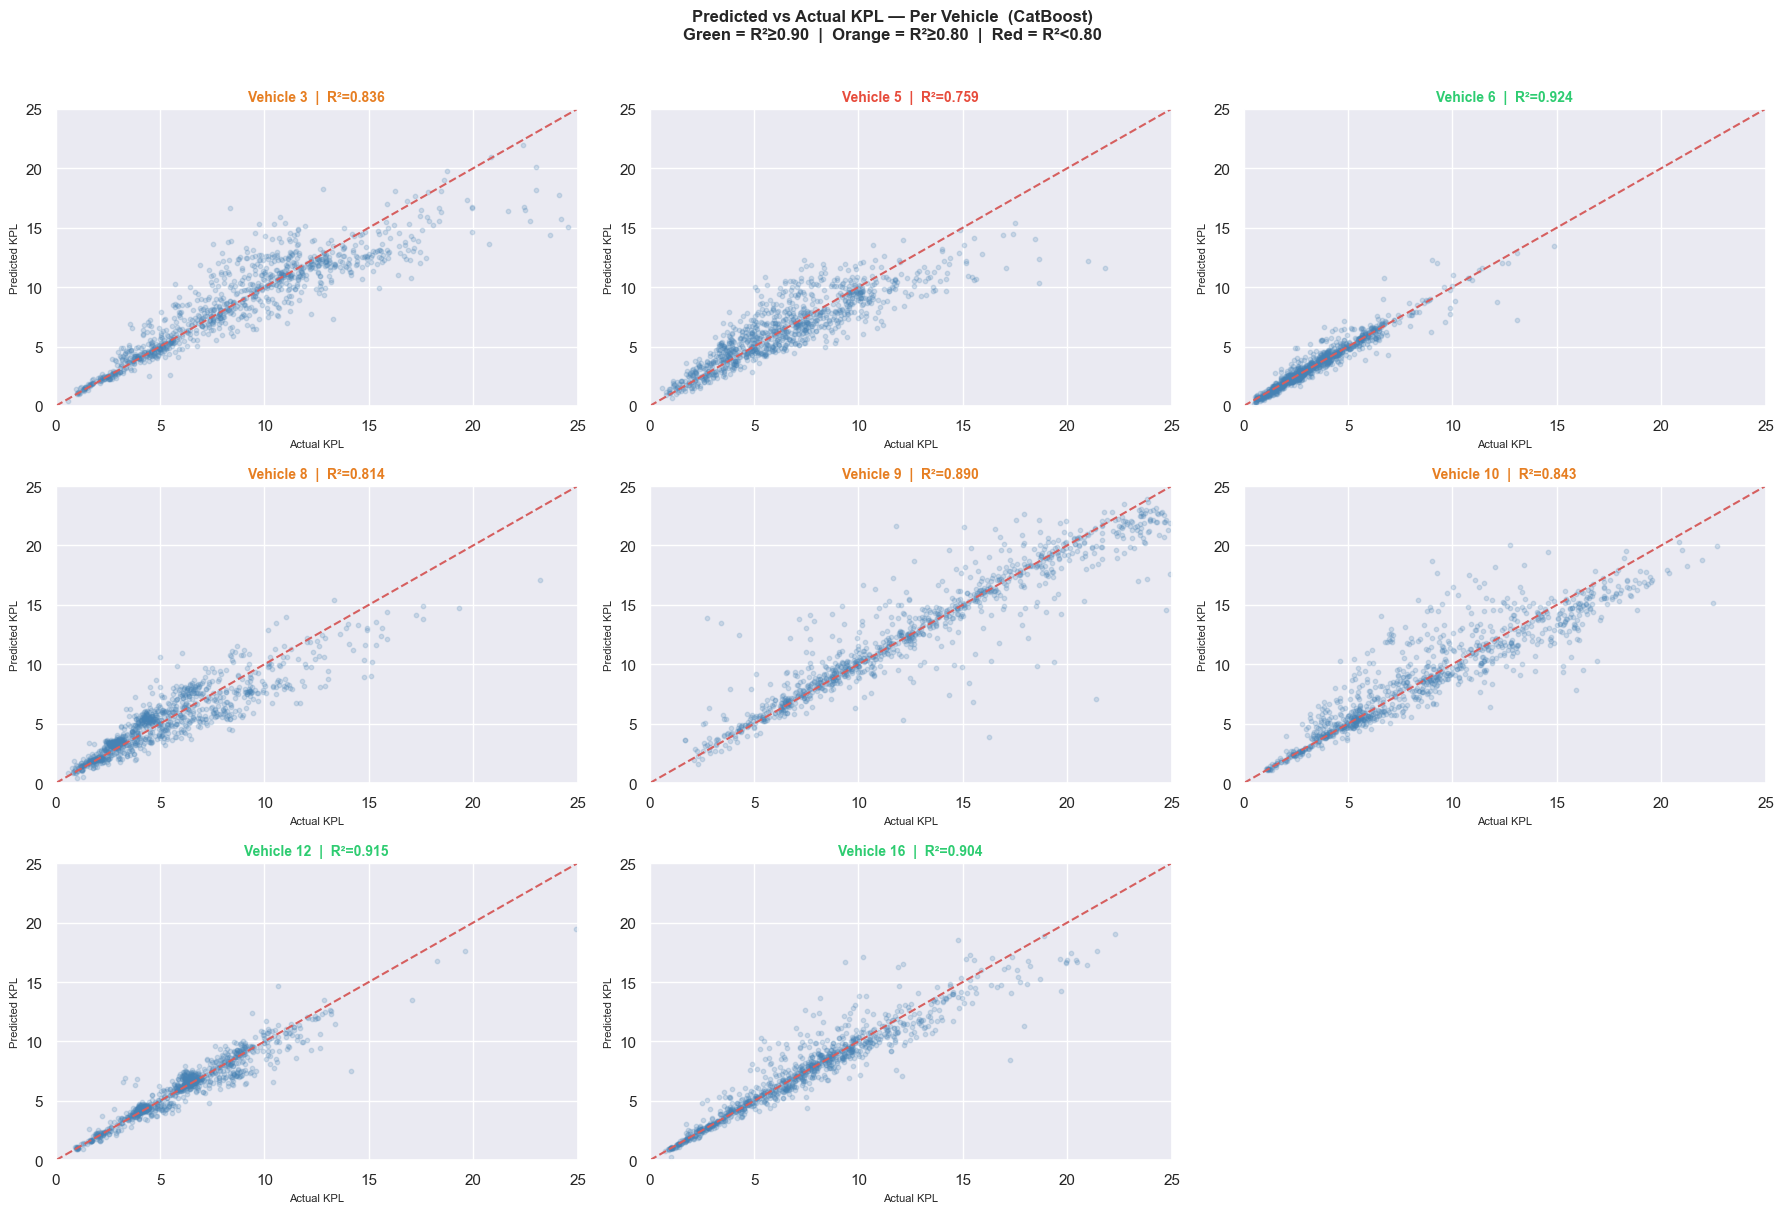

Saved -> outputs/07_per_vehicle_predictions.png


In [33]:
df_test              = X_test.copy()
df_test['actual']    = y_test
df_test['predicted'] = y_pred

devices = sorted(df_test['deviceID'].unique())
n_cols  = 3
n_rows  = -(-len(devices) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, dev_id in enumerate(devices):
    ax     = axes[i]
    subset = df_test[df_test['deviceID'] == dev_id].sample(
        min(1000, (df_test['deviceID'] == dev_id).sum()), random_state=42
    )
    r2_dev = r2_score(subset['actual'], subset['predicted'])
    title_color = '#2ecc71' if r2_dev >= 0.90 else '#e67e22' if r2_dev >= 0.80 else '#e74c3c'

    ax.scatter(subset['actual'], subset['predicted'], alpha=0.2, s=10, color='steelblue')
    ax.plot([0,25],[0,25], 'r--', lw=1.5)
    ax.set_xlim([0,25])
    ax.set_ylim([0,25])
    ax.set_title(f'Vehicle {int(dev_id)}  |  R²={r2_dev:.3f}',
                 fontweight='bold', fontsize=10, color=title_color)
    ax.set_xlabel('Actual KPL', fontsize=8)
    ax.set_ylabel('Predicted KPL', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Predicted vs Actual KPL — Per Vehicle  (CatBoost)\n'
    'Green = R²≥0.90  |  Orange = R²≥0.80  |  Red = R²<0.80',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/07_per_vehicle_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/07_per_vehicle_predictions.png')

## 7. Feature Importance

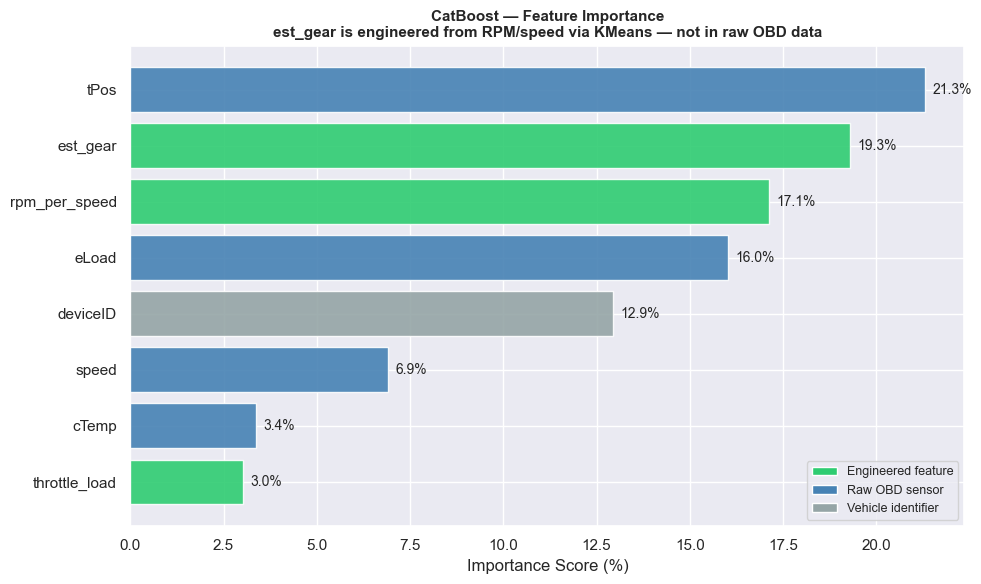

Saved -> outputs/08_feature_importance.png


In [34]:
imp = pd.Series(
    cb_model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=True)

# Color: green = engineered features, blue = raw OBD, gray = identifier
engineered = ['est_gear', 'rpm_per_speed', 'throttle_load']
identifier = ['deviceID']
colors = [
    '#2ecc71' if f in engineered else
    '#95a5a6' if f in identifier else
    'steelblue'
    for f in imp.index
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(imp.index, imp.values, color=colors, edgecolor='white', alpha=0.9)

for i, v in enumerate(imp.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Engineered feature'),
    Patch(facecolor='steelblue', label='Raw OBD sensor'),
    Patch(facecolor='#95a5a6', label='Vehicle identifier'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title(
    'CatBoost — Feature Importance\n'
    'est_gear is engineered from RPM/speed via KMeans — not in raw OBD data',
    fontweight='bold', fontsize=11
)
ax.set_xlabel('Importance Score (%)')

plt.tight_layout()
plt.savefig('../outputs/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/08_feature_importance.png')

## 8. Key Findings

In [35]:
engineered_total = imp[['est_gear','rpm_per_speed','throttle_load']].sum()
raw_obd_total    = imp[['tPos','eLoad','speed','cTemp']].sum()

print('=' * 65)
print('  CATBOOST FINAL MODEL — RESULTS')
print('=' * 65)
print(f'  R²   : {r2:.4f}')
print(f'  RMSE : {rmse:.4f} kpl')
print(f'  MAE  : {mae:.4f} kpl')
print()
print('  FEATURE IMPORTANCE')
print('=' * 65)
for feat, val in imp.sort_values(ascending=False).items():
    tag = '  ← engineered' if feat in engineered else \
          '  ← vehicle id' if feat in identifier else ''
    print(f'  {feat:<20} {val:5.1f}%{tag}')
print()
print(f'  Engineered features total : {engineered_total:.1f}%')
print(f'  Raw OBD sensors total     : {raw_obd_total:.1f}%')
print(f'  Vehicle identifier        : {imp["deviceID"]:.1f}%')
print('=' * 65)
print()
print('  KEY INSIGHT')
print('  Gear position (est_gear) and throttle (tPos) together account')
print('  for ~38% of predictive power — consistent with ECU injection')
print('  logic where gear selection and throttle demand are the primary')
print('  determinants of fuel injection quantity.')

  CATBOOST FINAL MODEL — RESULTS
  R²   : 0.8928
  RMSE : 1.5267 kpl
  MAE  : 0.9257 kpl

  FEATURE IMPORTANCE
  tPos                  21.3%
  est_gear              19.3%  ← engineered
  rpm_per_speed         17.1%  ← engineered
  eLoad                 16.0%
  deviceID              12.9%  ← vehicle id
  speed                  6.9%
  cTemp                  3.4%
  throttle_load          3.0%  ← engineered

  Engineered features total : 39.5%
  Raw OBD sensors total     : 47.6%
  Vehicle identifier        : 12.9%

  KEY INSIGHT
  Gear position (est_gear) and throttle (tPos) together account
  for ~38% of predictive power — consistent with ECU injection
  logic where gear selection and throttle demand are the primary
  determinants of fuel injection quantity.
